In [ ]:
from google.colab import files

print("Please upload the 'True.csv' and 'Fake.csv' files.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please upload the 'True.csv' and 'Fake.csv' files.


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv
User uploaded file "Fake.csv" with length 62789876 bytes
User uploaded file "True.csv" with length 53582940 bytes


In [ ]:
import pandas as pd

# Load the datasets
true_news = pd.read_csv('True.csv')
fake_news = pd.read_csv('Fake.csv')

# Add our target labels (0 for Real, 1 for Fake)
true_news['label'] = 0
fake_news['label'] = 1

# Combine both datasets into one main DataFrame
df = pd.concat([true_news, fake_news], ignore_index=True)

# Shuffle the data so the model doesn't learn the order
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Inspect the combined data
print(df.info())
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


In [ ]:
import re
import string
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK Ncessary NLTK Dictionaries
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize our stopword list and our lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    # 1. Convert everything to lowercase
    text = str(text).lower()

    # 2. Remove all punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # 3. Split the text into individual words
    words = text.split()

    # 4. In a single sweep: keep the word if it's not a stopword, AND lemmatize it!
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 5. Join the surviving, root words back into a single string
    return " ".join(processed_words)

# Apply our highly efficient function!
print("Applying the master cleaning function... ⏳")
df['cleaned_content'] = df['text'].apply(clean_and_lemmatize)

# Let's see the masterpiece
display(df[['text', 'cleaned_content']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Applying the master cleaning function... ⏳


,text,cleaned_content
0,"Donald Trump s White House is in chaos, and th...",donald trump white house chaos trying cover ru...
1,Now that Donald Trump is the presumptive GOP n...,donald trump presumptive gop nominee time reme...
2,Mike Pence is a huge homophobe. He supports ex...,mike penny huge homophobe support exgay conver...
3,SAN FRANCISCO (Reuters) - California Attorney ...,san francisco reuters california attorney gene...
4,Twisted reasoning is all that comes from Pelos...,twisted reasoning come pelosi day especially 2...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
# max_features=5000 means we only want to keep the top 5,000 most important words.
# (If we kept every single unique word, our computer might run out of memory!)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

print("Converting text to numbers... ⏳")
# We use fit_transform to 'learn' the vocabulary and 'transform' the text into a matrix of numbers
X = tfidf_vectorizer.fit_transform(df['cleaned_content'])

# Let's assign our target label to a separate variable 'y'
y = df['label'].values

print(f"Shape of X (our text numbers): {X.shape}")
print(f"Shape of y (our answer key): {y.shape}")

# Let's peek at the actual words the computer decided were the most important!
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample of the vocabulary words our model learned:")
print(feature_names[1000:1015])

Converting text to numbers... ⏳
Shape of X (our text numbers): (44898, 5000)
Shape of y (our answer key): (44898,)

Sample of the vocabulary words our model learned:
['complex' 'compliance' 'complicated' 'comply' 'compound' 'comprehensive'
 'compromise' 'computer' 'concept' 'concern' 'concerned' 'concerning'
 'concert' 'concession' 'concluded']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Split the data (80% for training, 20% for testing)
# random_state ensures we get the exact same random split if we run the code again tomorrow
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape} (Articles the AI will study)")
print(f"Testing data shape:  {X_test.shape}  (Articles locked in the vault for the exam)")

# 2. Initialize our Algorithm
# max_iter=1000 just gives the algorithm enough time to find the best mathematical patterns
model = LogisticRegression(max_iter=1000)

print("\nTraining the AI... 🧠 (This is where the magic happens!)")
# 3. 'fit' is the command that actually tells the model to learn from the Training Set
model.fit(X_train, y_train)

print("Training complete! Now let's take the final exam...")
# 4. 'predict' asks the model to look at the Test Set text and guess if each article is Real (0) or Fake (1)
y_pred = model.predict(X_test)

print("\nPredictions are in! 📝")

Training data shape: (35918, 5000) (Articles the AI will study)
Testing data shape:  (8980, 5000)  (Articles locked in the vault for the exam)

Training the AI... 🧠 (This is where the magic happens!)
Training complete! Now let's take the final exam...

Predictions are in! 📝


📝 Final Exam Results: Logistic Regression

               precision    recall  f1-score   support

Real News (0)       0.98      0.99      0.99      4311
Fake News (1)       0.99      0.99      0.99      4669

     accuracy                           0.99      8980
    macro avg       0.99      0.99      0.99      8980
 weighted avg       0.99      0.99      0.99      8980


Confusion matrix saved as 'confusion_matrix.png'!


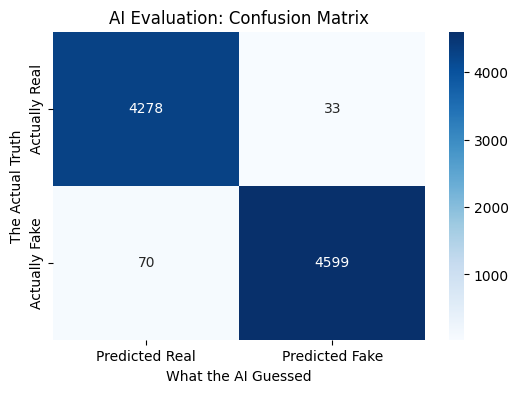

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("📝 Final Exam Results: Logistic Regression\n")

# 1. Print the Classification Report
print(classification_report(y_test, y_pred, target_names=['Real News (0)', 'Fake News (1)']))

# 2. Create a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it nicely using seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actually Real', 'Actually Fake'])
plt.title('AI Evaluation: Confusion Matrix')
plt.xlabel('What the AI Guessed')
plt.ylabel('The Actual Truth')

# Save the plot so we can view our results
plt.savefig('confusion_matrix.png')
print("\nConfusion matrix saved as 'confusion_matrix.png'!")